# <b>Fifth stage: Class Creation for Machine Learning</b>

## 5.1.1 Determination of Production Ranges

<div style='text-align: justify'>For the machine learning analysis, biomass and NADH production will be divided into two classes so that the classifier can identify which enzymes are most important for class determination. To achieve this, two thresholds will be defined: one for NADH production (N) and another for biomass production (B). Based on these limits, two classes will be created for the flux combinations according to the following criteria:</div><br>
<div style='text-align: centered'><b>1. If the NADH production of a combination is greater than or equal to N and the biomass production is greater than B, the combination is assigned to class 1.</b></div>
<div style='text-align: centered'><b>2. If either NADH production or biomass production does not meet the criteria defined in (1), the combination is assigned to class 0.</b></div><br>
<div style='text-align: justify'>In this way, a Random Forest classifier will be applied using the flux dataset as features and the production classes (0 and 1) as the target variable.</div>

<div style='text-align: justify'><b>N and B determination:</b> For the biomass threshold (B), only values <b>above</b> 0.01 mmol/gDW/h will be considered, which corresponds to approximately 10% of the biomass production under wild anaerobic conditions (0.1032 mmol/gDW/h). Thus, it is important to ensure that the bacterium retains sufficient capacity to sustain its vital functions. For NADH production, however, the distribution of the data must first be examined in order to define an appropriate threshold.</div>

In [1]:
# Packages for data manipulation and visualization

import pandas as pd
import math
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset containing all combinations and productions
df = pd.read_csv('../Datasets/Final_Data.csv')

<div style='text-align: justify'><b>For N determination, we will visualize the dataset in order to get some valuable informations.</b></div>

Text(0, 0.5, 'Biomass [h⁻¹]')

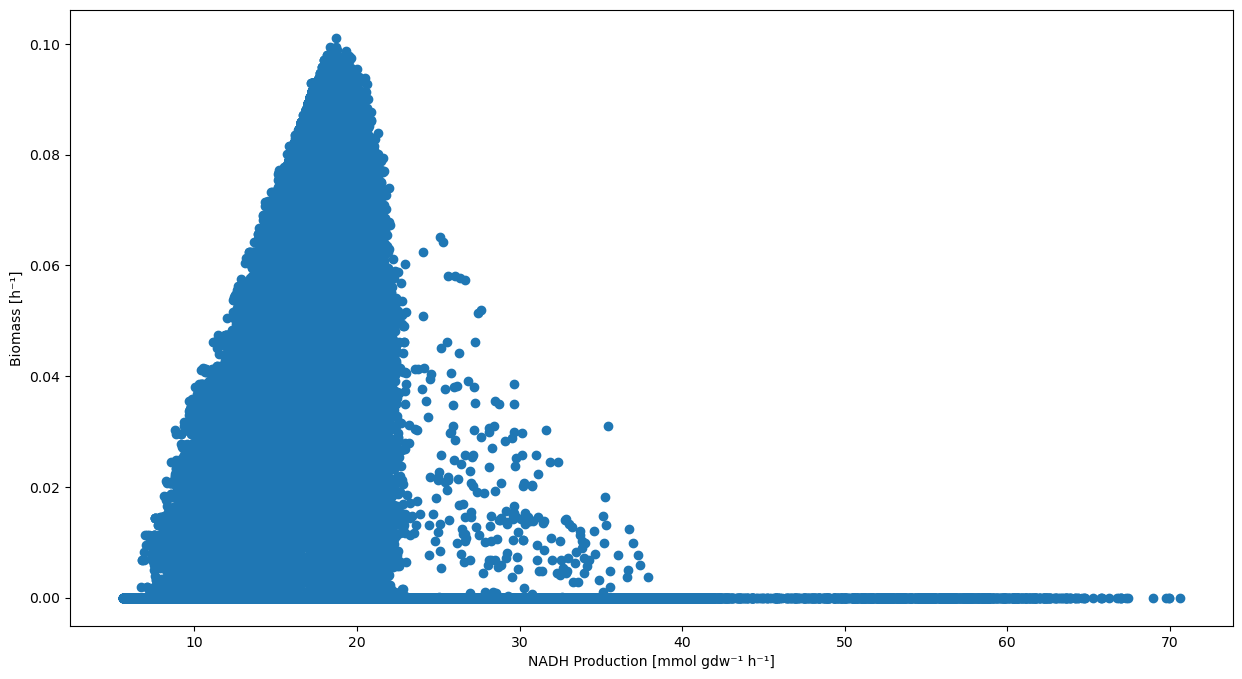

In [3]:
# Data visualization

fig, ax = plt.subplots(figsize=(15,8))

plot1 = ax.scatter(df['NADH Production'],df['Biomass'])
ax.set_xlabel('NADH Production [mmol gdw⁻¹ h⁻¹]')
ax.set_ylabel('Biomass [h⁻¹]')

<div style='text-align: justify'>As observed, at low NADH production levels the bacterium is unable to maintain adequate biomass formation, since catabolic pathways become less efficient for energy generation. As NADH production increases, biomass production also rises, reaching its maximum when NADH approaches approximately 18 mmol/gDW/h. This behavior is consistent with the results presented in Part 1, where under anaerobic conditions the model predicts NADH production of 18.5269 mmol/gDW/h and a maximum biomass yield of 0.1032 mmol/gDW/h. Finally, when NADH production becomes substantially higher than this range, biomass production decreases markedly, and only a small number of combinations are able to sustain biomass formation above zero.</div><br>

<div style='text-align: justify'><b>Thus, the NADH production threshold will be defined to represent a scenario in which both NADH and biomass are maintained at relatively high levels, as follows: </b></div>
<ol>
    <li><b>NADH production (N) above or equal 24 mmol/gDW/h.</b> This threshold was chosen for three reasons: (i) it represents a suitable range of NADH production values (approximately 24–40 mmol/gDW/h); (ii) it includes a large number of combinations; and (iii) it retains combinations with relatively high biomass production. Under this scenario, the objective is to identify which enzymes most strongly contribute to increased NADH production without compromising biomass formation.</li>
</ol>

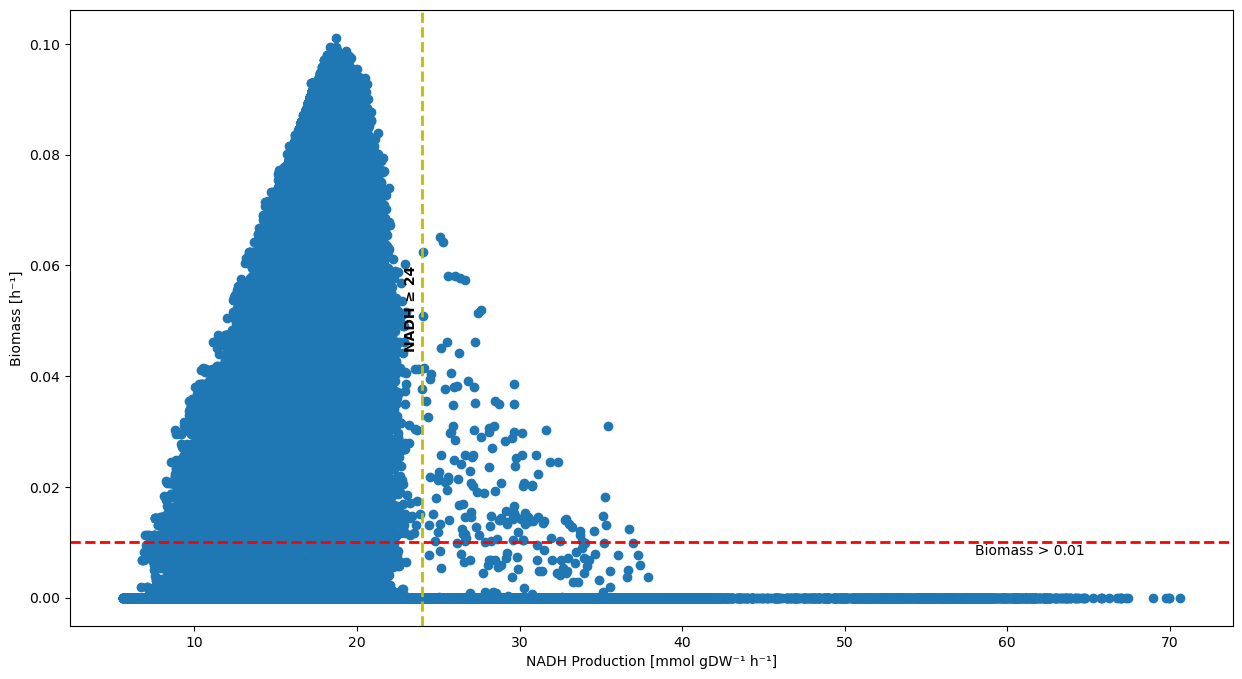

In [9]:
# Data visualization for scenario 1

fig, ax = plt.subplots(figsize=(15,8))

plot1 = ax.scatter(df['NADH Production'],df['Biomass'])
ax.set_xlabel('NADH Production [mmol gDW⁻¹ h⁻¹]')
ax.set_ylabel('Biomass [h⁻¹]')
ax.axhline(y=0.01, color='r', linestyle='--', linewidth=2)
ax.axvline(x=24, color='y', linestyle='--', linewidth=2)
ax.text(58, 0.0078, 'Biomass > 0.01')
ax.text(22.9, 0.045, 'NADH ≥ 24', rotation = 90, color='k', weight = 'bold')

#fig.savefig('../Images/ML_Classes.png',dpi=1200)

In [10]:
# Number of combinations classified as class 1 under these threshold restrictions.
df.loc[(df['NADH Production'] >= 24) & (df['Biomass'] > 0.01)].count()

PDH_fw             146
PPC_fw             146
CS_fw              146
ACONTa_fw          146
ACONTa_bw          146
ACONTb_fw          146
ACONTb_bw          146
ICDHyr_fw          146
ICDHyr_bw          146
AKGDH_fw           146
SUCOAS_fw          146
SUCOAS_bw          146
FUM_fw             146
FUM_bw             146
FRD2_fw            146
ICL_fw             146
ICL_bw             146
MALS_fw            146
NADH Production    146
Biomass            146
dtype: int64

<div style='text-align: justify'>As we can see, the number of combinations in class 1 is very small compared with the total number of combinations (1,000,000). Therefore, class balancing will be required to ensure proper performance of the classification algorithm (see Part 5.2).</div>

In [11]:
# Valuable informations of the class 1
df.loc[(df['NADH Production'] >= 24) & (df['Biomass'] > 0.01)].describe()[['NADH Production','Biomass']]

,NADH Production,Biomass
count,146.000000,146.000000
mean,28.291682,0.024009
std,2.830440,0.013107
min,24.052530,0.010051
25%,25.995098,0.013887
50%,27.865888,0.020640
75%,30.135123,0.030138
max,36.713736,0.065141


<div style='text-align: justify'>As observed, under these threshold restrictions the dataset covers NADH production values between 24 and 36 mmol/gDW/h and, importantly, includes relatively high biomass yields (0.01–0.07 mmol/gDW/h).</div>

## 5.1.2 Creation of Conditions Data Frame

<div style='text-align: justify'>Before proceeding to the machine learning algorithm, a data frame must be created to represent the class labels (0 or 1), which will serve as the target variable.</div>

In [12]:
# The function for classes definition

def classes(row):
   if (row['Biomass'] == 1) & (row['NADH Production'] == 1):
      return 1
   else: 
      return 0

In [13]:
# Creation of data frame with classes

R_imp_final = ['PDH_fw','PPC_fw','CS_fw','ACONTa_fw','ACONTa_bw',
               'ACONTb_fw','ACONTb_bw','ICDHyr_fw','ICDHyr_bw',
               'AKGDH_fw','SUCOAS_fw','SUCOAS_bw','FUM_fw','FUM_bw',
               'FRD2_fw','ICL_fw','ICL_bw','MALS_fw']

df['Biomass'] = df['Biomass'].apply(lambda x: 1 if x >= 0.01 else 0)
df['NADH Production'] = df['NADH Production'].apply(lambda x: 1 if x >= 24 else 0)

df_target = df.copy()

df_target['Classes'] = df_target.apply(classes,axis=1)

df_target = df_target.drop(R_imp_final,axis='columns')

df_target

,NADH Production,Biomass,Classes
0,0,0,0
1,0,1,0
2,0,0,0
3,0,0,0
4,0,1,0
...,...,...,...
999995,0,0,0
999996,0,0,0
999997,0,0,0
999998,0,0,0


In [14]:
# To check if the number of combinations in class one is 146
df_target.loc[(df_target['Classes'] == 1)].count()

NADH Production    146
Biomass            146
Classes            146
dtype: int64

In [15]:
# Therefore, the features dataset is the df without biomass and NADH columns
df_features = df.copy()

df_features = df_features.drop(['NADH Production', 'Biomass'],axis='columns')

df_features

,PDH_fw,PPC_fw,CS_fw,ACONTa_fw,ACONTa_bw,ACONTb_fw,ACONTb_bw,ICDHyr_fw,ICDHyr_bw,AKGDH_fw,SUCOAS_fw,SUCOAS_bw,FUM_fw,FUM_bw,FRD2_fw,ICL_fw,ICL_bw,MALS_fw
0,0.173741,0.381363,0.273401,1.252237,0.978835,0.815568,0.542166,0.294749,0.283189,0.000000,0.000000,0.000000,0.000000,0.369804,0.369804,1.161967,0.900125,0.261842
1,0.000000,3.237578,0.229919,2.535450,2.305531,1.725970,1.496051,1.362675,1.132756,0.000000,0.985846,0.950869,1.100465,1.479215,0.448039,1.161967,1.161967,0.000000
2,0.173741,2.504546,0.261842,2.020747,1.758905,2.430507,2.168665,0.099471,0.099471,0.000000,0.492923,0.492923,0.370528,2.875074,2.504546,2.198454,1.936612,0.261842
3,0.521223,1.074011,0.000000,1.252237,1.252237,0.641637,0.641637,0.382660,0.382660,0.000000,2.437544,2.437544,0.741057,1.815067,1.074011,1.161967,1.161967,0.000000
4,1.563670,1.038482,0.483726,1.252237,0.768510,3.736724,3.252998,1.232227,1.168125,0.000000,0.031402,0.000000,0.000000,0.000000,0.062208,1.968913,1.549290,0.419624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.521223,0.656696,0.360367,1.636492,1.276125,0.360367,0.000000,1.515416,1.515416,0.000000,1.971692,1.971692,1.111585,1.768281,0.656696,3.071623,2.711257,0.360367
999996,1.563670,2.871062,0.361313,0.867981,0.506668,0.361313,0.000000,0.665849,0.566378,0.099471,3.943385,4.042856,0.000000,0.207693,0.207693,1.423809,1.161967,0.261842
999997,0.521223,0.305451,0.360367,2.789257,2.428891,1.444699,1.084333,2.480412,2.265513,0.000000,0.000000,0.000000,1.018860,1.109411,0.090552,2.082080,1.936612,0.145468
999998,1.216188,0.865354,0.145468,0.867981,0.722514,4.436801,4.291333,0.382660,0.382660,0.000000,3.412562,3.412562,0.000000,0.865354,0.865354,1.694757,1.549290,0.145468


In [16]:
# Saving the data frames

path = '../Datasets/'
target = 'targets_final.csv'
features = 'features.csv'

#df_features.to_csv(path+features,index=False)
#df_target.to_csv(path+target,index=False)

## <b>End of Part 5.1!</b>